# Multi-Group Violin Probability Density Analysis

Violin plots combine box plots and kernel density plots to visualize the distribution shape, probability density, and summary statistics of numerical columns across categories. This notebook generates synthetic performance metrics across four corporate divisions (R&D, Sales, Marketing, HR) and visualizes distributions using a customized Seaborn Violin plot.



In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Generate synthetic performance scores (800 records across 4 departments)
np.random.seed(60)
n_samples = 800

departments = np.random.choice(['R&D', 'Sales', 'Marketing', 'HR'], size=n_samples, p=[0.3, 0.25, 0.25, 0.2])

# Performance score distributions vary per department (e.g. R&D has high variance)
scores = []
for dept in departments:
    if dept == 'R&D':
        score = np.random.normal(82, 9)
    elif dept == 'Sales':
        score = np.random.normal(76, 7)
    elif dept == 'Marketing':
        score = np.random.normal(79, 6)
    else: # HR
        score = np.random.normal(73, 5)
    scores.append(score)

# Clip scores to [50, 100]
scores = np.clip(scores, 50, 100)

df_perf = pd.DataFrame({
    'Department': departments,
    'Performance_Score': scores
})

df_perf.head(10)



,Department,Performance_Score
0,Sales,70.046864
1,R&D,85.040420
2,Sales,75.795184
3,Marketing,70.403331
4,Marketing,82.805308
5,Sales,69.256408
6,Sales,60.552660
7,R&D,75.941806
8,R&D,91.976647
9,R&D,94.798441


## Descriptive Statistics Aggregations

We calculate the mean, median, standard deviation, and sample counts for each department category to support the visual data profiles.



In [2]:
df_stats = df_perf.groupby('Department')['Performance_Score'].agg(['count', 'mean', 'median', 'std'])
print("Department Performance Statistics:")
df_stats



Department Performance Statistics:


,count,mean,median,std
Department,,,,
HR,144,72.764546,72.428083,5.070149
Marketing,191,78.952326,79.009842,6.354051
R&D,252,81.490265,81.502627,8.866855
Sales,213,76.476154,76.268186,6.649293


## Annotated Multi-Group Violin Plot

Using Seaborn, we visualize the department distributions as a vertical violin plot, overlaying inner quartile lines and adding custom styling.



<cell>:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


<cell>:4: FutureWarning:



The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.

<cell>:18: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



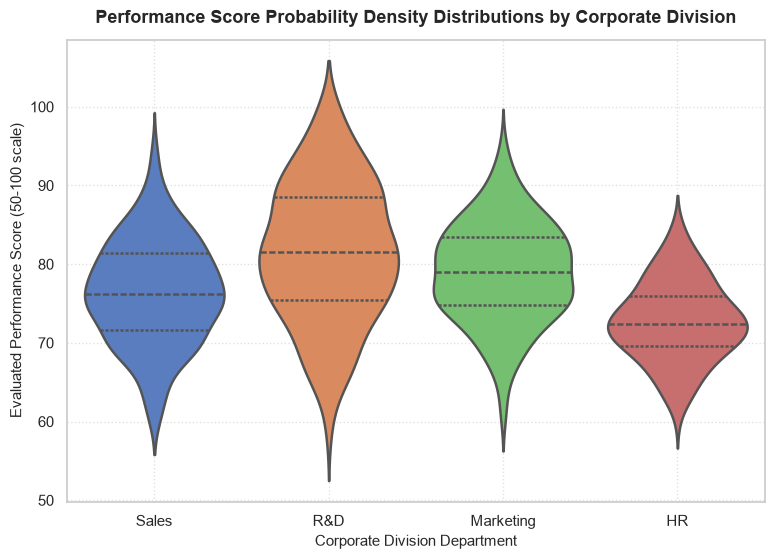

In [3]:
plt.figure(figsize=(9, 6))

# Plot violins
sns.violinplot(
    x='Department', 
    y='Performance_Score', 
    data=df_perf, 
    palette='muted',
    inner='quartile', # Show quartiles inside the violins
    linewidth=1.8,
    scale='width'
)

plt.title('Performance Score Probability Density Distributions by Corporate Division', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Corporate Division Department', fontsize=11)
plt.ylabel('Evaluated Performance Score (50-100 scale)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
